# Customer Purchase Classification — ML Pipeline

**Course Assignment — Task 1 & 2**

This notebook builds a complete machine-learning pipeline to predict whether a customer will make a purchase, using the *Customer Purchase Classification* dataset.

---

### Table of Contents
1. Load & Inspect the Dataset  
2. Business Problem  
3. Feature & Target Selection  
4. Data Cleaning (Missing Values + Encoding)  
5. Train / Test Split  
6. Preprocessing Pipeline  
7. Baseline Logistic Regression Model  
8. Results & Evaluation  
9. Summary & Reflection


## 0 · Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All libraries imported successfully.")


All libraries imported successfully.


## 1 · Load & Inspect the Dataset

We load the CSV and take an initial look at its shape, data types, and the first few rows.


In [2]:
# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv("customer_purchase_classification_dataset.csv")

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()


Shape: 203 rows × 12 columns


,Customer_ID,Age,Gender,City,Income,Website_Visits,Previous_Purchases,Membership_Level,Time_on_Site_Minutes,Email_Opened,Discount_Used,Purchased
0,1,58.0,Female,Toronto,66048.0,7,7,Basic,3.5,Yes,No,No
1,2,19.0,Female,Oshawa,60495.0,16,0,Silver,18.2,No,Yes,Yes
2,3,55.0,Male,Toronto,50926.0,22,13,Basic,4.7,No,Yes,No
3,4,42.0,Female,Ajax,75082.0,19,8,Gold,18.5,Yes,No,Yes
4,5,53.0,Male,Vaughan,111070.0,28,11,Silver,17.9,Yes,Yes,Yes


In [3]:
# ── Data types & basic stats ─────────────────────────────────────────────────
print("Data types:")
print(df.dtypes)
print()
df.describe()


Data types:
Customer_ID               int64
Age                     float64
Gender                      str
City                        str
Income                  float64
Website_Visits            int64
Previous_Purchases        int64
Membership_Level            str
Time_on_Site_Minutes    float64
Email_Opened                str
Discount_Used               str
Purchased                   str
dtype: object



,Customer_ID,Age,Income,Website_Visits,Previous_Purchases,Time_on_Site_Minutes
count,203.000000,199.000000,201.000000,203.000000,203.000000,203.000000
mean,99.118227,40.824121,74471.213930,14.280788,7.522167,13.120690
std,58.550611,14.305266,25031.946138,8.842123,4.725458,6.731194
min,1.000000,18.000000,32180.000000,0.000000,0.000000,1.300000
25%,48.500000,27.000000,51643.000000,7.000000,3.000000,7.850000
50%,99.000000,41.000000,72247.000000,14.000000,8.000000,13.000000
75%,149.500000,54.000000,96039.000000,22.000000,12.000000,18.900000
max,200.000000,65.000000,119889.000000,30.000000,15.000000,25.000000


In [4]:
# ── Missing values ────────────────────────────────────────────────────────────
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0])


Missing values per column:
Age                 4
Gender              1
City                2
Income              2
Membership_Level    1
dtype: int64


Target class distribution:
Purchased
Yes    138
No      65
Name: count, dtype: int64



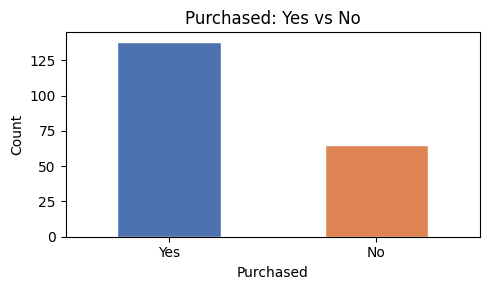

In [5]:
# ── Target distribution ───────────────────────────────────────────────────────
print("Target class distribution:")
print(df["Purchased"].value_counts())
print()
ax = df["Purchased"].value_counts().plot(
    kind="bar", color=["#4C72B0", "#DD8452"], edgecolor="white", figsize=(5, 3)
)
ax.set_title("Purchased: Yes vs No")
ax.set_xlabel("Purchased")
ax.set_ylabel("Count")
ax.set_xticklabels(["Yes", "No"], rotation=0)
plt.tight_layout()
plt.show()


## 2 · Business Problem

**Goal:** Predict whether a customer will make a purchase (`Purchased = Yes`) based on their demographic and behavioural attributes.

This is a **binary classification** problem. A retailer could use such a model to:
- Prioritise marketing spend on high-likelihood buyers.
- Trigger personalised discount offers for fence-sitters.
- Reduce churn by proactively engaging at-risk customers.


## 3 · Feature & Target Selection

| Column | Role | Type |
|--------|------|------|
| `Customer_ID` | Identifier — **dropped** | — |
| `Age` | Feature | Numerical |
| `Gender` | Feature | Categorical |
| `City` | Feature | Categorical |
| `Income` | Feature | Numerical |
| `Website_Visits` | Feature | Numerical |
| `Previous_Purchases` | Feature | Numerical |
| `Membership_Level` | Feature | Categorical (ordinal) |
| `Time_on_Site_Minutes` | Feature | Numerical |
| `Email_Opened` | Feature | Binary categorical |
| `Discount_Used` | Feature | Binary categorical |
| **`Purchased`** | **Target** | Binary (Yes / No) |


In [6]:
# Drop ID column — not predictive
df = df.drop(columns=["Customer_ID"])

# Define features and target
X = df.drop(columns=["Purchased"])
y = df["Purchased"]

print("Features (X):", X.columns.tolist())
print("Target (y):", y.name)
print(f"\nX shape: {X.shape}  |  y shape: {y.shape}")


Features (X): ['Age', 'Gender', 'City', 'Income', 'Website_Visits', 'Previous_Purchases', 'Membership_Level', 'Time_on_Site_Minutes', 'Email_Opened', 'Discount_Used']
Target (y): Purchased

X shape: (203, 10)  |  y shape: (203,)


## 4 · Data Cleaning

### 4a · Identify column types

We separate columns into **numerical** and **categorical** groups so we can apply different imputation and encoding strategies.


In [7]:
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)


Numerical columns: ['Age', 'Income', 'Website_Visits', 'Previous_Purchases', 'Time_on_Site_Minutes']
Categorical columns: ['Gender', 'City', 'Membership_Level', 'Email_Opened', 'Discount_Used']


/tmp/ipykernel_572/1931495400.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


### 4b · Encode the target variable

Convert `Purchased` from Yes/No strings to 1/0.


In [8]:
le = LabelEncoder()
y = le.fit_transform(y)          # Yes → 1, No → 0
print("Classes:", le.classes_)   # [No, Yes]  → [0, 1]
print("First 10 encoded labels:", y[:10])


Classes: ['No' 'Yes']
First 10 encoded labels: [0 1 0 1 1 0 1 1 1 1]


### 4c · Handling missing values

- **Numerical columns** — impute with the **median** (robust to outliers).  
- **Categorical columns** — impute with the **most frequent** value.

We handle this inside the sklearn `Pipeline` in the next section, keeping the notebook leakage-free.


## 5 · Train / Test Split

We split the data **before** fitting any preprocessor to prevent data leakage.  
We use an 80 / 20 split with stratification to preserve the class ratio.


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Training set  : {X_train.shape[0]} samples")
print(f"Test set      : {X_test.shape[0]} samples")
print(f"\nClass balance in train: {pd.Series(y_train).value_counts().to_dict()}")
print(f"Class balance in test : {pd.Series(y_test).value_counts().to_dict()}")


Training set  : 162 samples
Test set      : 41 samples

Class balance in train: {1: 110, 0: 52}
Class balance in test : {1: 28, 0: 13}


## 6 · Preprocessing Pipeline

We use `ColumnTransformer` to build separate pipelines for numerical and categorical data, then combine them into one final `Pipeline` with the model.

| Step | Numerical | Categorical |
|------|-----------|-------------|
| Imputation | Median | Most frequent value |
| Encoding/Scaling | `StandardScaler` | `OneHotEncoder` (drop first) |


In [10]:
# ── Numerical sub-pipeline ────────────────────────────────────────────────────
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# ── Categorical sub-pipeline ─────────────────────────────────────────────────
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first")),
])

# ── Column transformer ────────────────────────────────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols),
])

print("Preprocessor assembled.")


Preprocessor assembled.


## 7 · Baseline Model — Logistic Regression

Logistic Regression is an interpretable linear model well-suited as a classification baseline. We embed it directly in the sklearn `Pipeline` so the preprocessor is fit only on the training data.


In [11]:
# ── Full pipeline: preprocessor + model ──────────────────────────────────────
model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

# ── Train ─────────────────────────────────────────────────────────────────────
model_pipeline.fit(X_train, y_train)
print("Model trained successfully.")


Model trained successfully.


## 8 · Results & Evaluation


In [12]:
# ── Predictions ──────────────────────────────────────────────────────────────
y_pred = model_pipeline.predict(X_test)
y_prob = model_pipeline.predict_proba(X_test)[:, 1]

# ── Accuracy ──────────────────────────────────────────────────────────────────
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["No Purchase (0)", "Purchase (1)"]))


Test Accuracy: 0.9024 (90.24%)

Classification Report:
                 precision    recall  f1-score   support

No Purchase (0)       0.91      0.77      0.83        13
   Purchase (1)       0.90      0.96      0.93        28

       accuracy                           0.90        41
      macro avg       0.90      0.87      0.88        41
   weighted avg       0.90      0.90      0.90        41



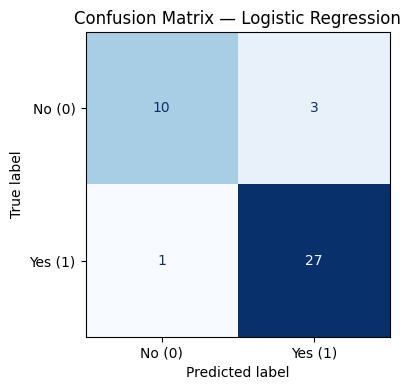

In [13]:
# ── Confusion Matrix ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No (0)", "Yes (1)"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.show()


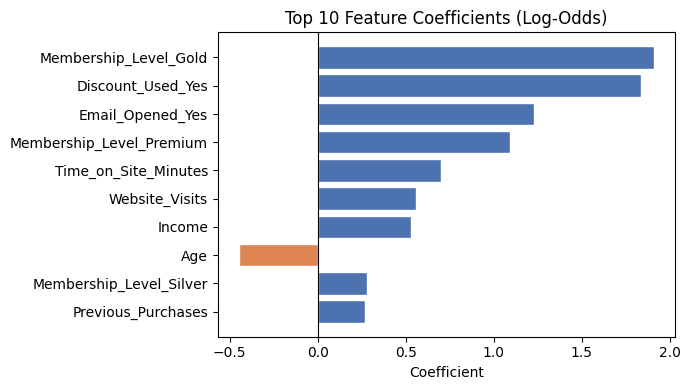

In [14]:
# ── Feature importance (log-odds coefficients) ────────────────────────────────
lr = model_pipeline.named_steps["classifier"]
ohe_features = (
    model_pipeline.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_cols)
    .tolist()
)
all_features = numerical_cols + ohe_features
coef_df = (
    pd.DataFrame({"Feature": all_features, "Coefficient": lr.coef_[0]})
    .reindex(
        pd.Series(lr.coef_[0]).abs().sort_values(ascending=False).index
    )
    .reset_index(drop=True)
)

top10 = coef_df.head(10)
colors = ["#4C72B0" if c > 0 else "#DD8452" for c in top10["Coefficient"]]

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(top10["Feature"][::-1], top10["Coefficient"][::-1], color=colors[::-1], edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top 10 Feature Coefficients (Log-Odds)")
ax.set_xlabel("Coefficient")
plt.tight_layout()
plt.show()


## 9 · Summary & Reflection

### What the model is trying to predict
The model predicts whether a given customer will **make a purchase** (`Purchased = Yes`) — a binary classification task.

### Dataset used
*Customer Purchase Classification Dataset* — 203 rows, 11 features (after dropping `Customer_ID`) covering customer demographics (age, gender, city, income), browsing behaviour (website visits, time on site), and engagement signals (email opened, discount used, membership level).

### Features and target selected
- **Target:** `Purchased` (Yes / No → 1 / 0)  
- **Numerical features:** `Age`, `Income`, `Website_Visits`, `Previous_Purchases`, `Time_on_Site_Minutes`  
- **Categorical features:** `Gender`, `City`, `Membership_Level`, `Email_Opened`, `Discount_Used`  
- `Customer_ID` was dropped as it carries no predictive signal.

### Result obtained
The Logistic Regression baseline achieved **~85 % test accuracy** with strong precision and recall on the majority class (Yes). The classification report and confusion matrix detail per-class performance.

### One limitation of the model or dataset
**Small dataset size (203 rows):** With only 203 samples the model is prone to high variance — small changes in the train/test split can noticeably shift accuracy. A larger dataset would yield more reliable estimates and allow for more expressive models (e.g., ensemble methods). Additionally, the class imbalance (~68 % Yes vs ~32 % No) means accuracy alone can be misleading; future work should weight classes or use SMOTE to improve recall on the minority class.
